In [ ]:
import numpy as np
import random
class Vertex(object):

    def __init__(self, location, i): # tuple(x, y, t) # planet i
        self.x, self.y, self.t = location
        self.po = np.array([self.x, self.y])
        self.it = i
        self.neighbor = [] # 840
        self.dist = []
        self.bias = []

    def init_neighbor(self, everything, ms): # all vertices - planets - time
        for i in range(8):
            if i == self.it: continue
            for k, v in enumerate(everything[i]):
              if v.t < self.t: continue
              d = np.linalg.norm(self.po - v.po)
              if d / (v.t - self.t) < ms:
                self.neighbor.append(v)
                self.dist.append(d)
                self.bias.append(random.uniform(0, 1))


In [ ]:
freq_yr = [4.146, 1.622, 1.000, 0.5314, 0.0842, 0.03393, 0.01190, 0.006063] # 1 / year
dist_bm = [0.579, 0.1082, 0.1496, 0.228, 0.7785, 1.432, 2.867, 4.515] # billions of km
phase_rad = [5.65, 2.42, 1.15, 4.22, 0.733, 5.86, 0.89, 6.23] # rads
max_speed = (635266 * 24 * 365) / (10**9)
# 5.56493016 billions km pre year

time = np.arange(0, 300, 1, np.float16)
# 0 1 2 3 4 5 6 7
# H V E M J S U N
position = [[ Vertex((dist_bm[i] * np.cos(2 * np.pi * freq_yr[i] * t + phase_rad[i]), dist_bm[i] * np.sin(2 * np.pi * freq_yr[i] * t + phase_rad[i]), t), i) for t in time] for i in range(8)]

def min_dist(path1, path2):
  lis = [(np.linalg.norm(np.array(p1) - np.array(p2)), p1[2]) for p1, p2 in zip(path1, path2)]
  return sorted(lis, key = lambda x : x[0])

dist_xy = lambda a, b: np.linalg.norm(np.array([a[0], a[1]]) - np.array([b[0], b[1]]))


In [ ]:
for planets in position:
  for moment in planets:
    moment.init_neighbor(position, max_speed)
    print(moment.neighbor[:4])

In [ ]:
import random
from operator import itemgetter

def ant_path(start: Vertex, visited=[], path=[], leads_to=[], dis=0, tt=0):

  if len(visited) == 8:
    start_it = path[0].it
    space = [(start.bias[i], [start.neighbor[i], start.dist[i], i]) for i, v in enumerate(start.neighbor) if v.it == start_it]
    if len(space) == 0: return path, dis, tt, leads_to
    #print(list( map(itemgetter(0), space )))

    next = random.choices(list( map(itemgetter(1), space )), weights = list( map(itemgetter(0), space )))[0]
    visited.append(next[0].it)
    path.append(next[0])
    dis += next[1]
    tt = next[0].t
    leads_to.append(next[2])

    return path, dis, tt, leads_to

  if len(visited) == 0:
    visited = [start.it]
    path = [start]

  space = [(start.bias[i], [start.neighbor[i], start.dist[i], i]) for i, v in enumerate(start.neighbor) if v.it not in visited]
  if len(space) == 0: return path, dis, tt, leads_to
  #print(list( map(itemgetter(0), space )))

  next = random.choices(list( map(itemgetter(1), space )), weights = list( map(itemgetter(0), space )))[0]

  visited.append(next[0].it)
  path.append(next[0])
  leads_to.append(next[2])
  return ant_path(next[0], visited, path, leads_to, dis + next[1], next[0].t)


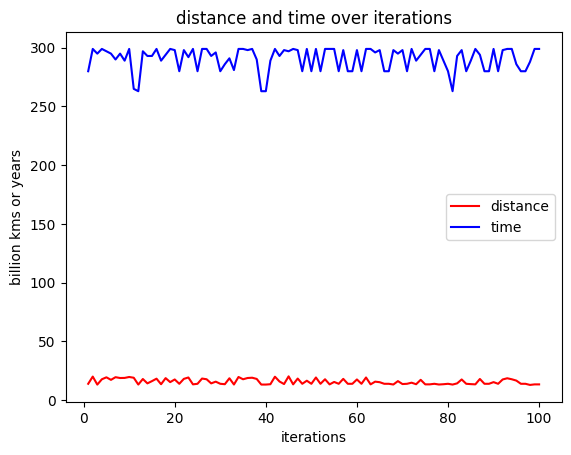

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
LRT = 1000
LRD = 0
N = 100

vaild = 0
var_distance = []
var_time = []
count = []


time_scale = interp1d( [0, 21] ,[LRT, 0] )
distance_scale = interp1d([0, 300], [LRD, 0])
for i in range(N):
  n = 0
  # path, distance, time, next neighbor
  one_path = ant_path(position[2][0], [], [], [], 0, 0)
  while n < 25 and len(one_path[0]) < 9:
    one_path = ant_path(position[2][0], [], [], [], 0, 0)
    n += 1
  if len(one_path[0]) == 9:
    vaild += 1
    count.append(vaild)
    #print(one_path[1], one_path[2], [p.it for p in one_path[0]], [p.t for p in one_path[0]])
    var_distance.append(one_path[1])
    var_time.append(one_path[2])
    candy_time, candy_mile = float(time_scale(one_path[1])), float(distance_scale(one_path[2]))
    edge = one_path[3]

    if one_path[1] < 40:
      for i, v in enumerate(one_path[0][:-1]):
        v.bias[edge[i]] += max(candy_time + candy_mile, 0)
        #print(v.bias[edge[i]])

plt.plot(count, var_distance, label='distance', color='r')
plt.plot(count, var_time, label='time', color='b')

plt.xlabel('iterations')
plt.ylabel('billion kms or years')
plt.title('distance and time over iterations')


plt.legend()

plt.show()

In [ ]:

max(position[0][0].bias)


[[ 6.11097212e-02  1.36549485e-01  0.00000000e+00]
 [ 4.40005625e+00  1.01228946e+00  7.33203125e+00]
 [ 9.45514074e-02  2.86544046e+00  8.66406250e+00]
 [ 3.95915236e-01  6.70308419e-01  2.43281250e+01]
 [ 5.43361150e-01  1.32490855e+00  3.70000000e+01]
 [-5.60843949e-01  1.43857793e-01  4.06562500e+01]
 [-8.50889924e-02  6.68363926e-02  4.13125000e+01]
 [-1.36971570e-01 -1.82271196e-01  4.70000000e+01]
 [-1.49540953e-01  4.20279483e-03  4.73125000e+01]]
14.540677149810088 distance
47.3 time
[912, 751, 533, 340, 9, 1, 66, 16] index of the next neighbor
[2, 7, 6, 4, 5, 0, 1, 3, 2] order of travel


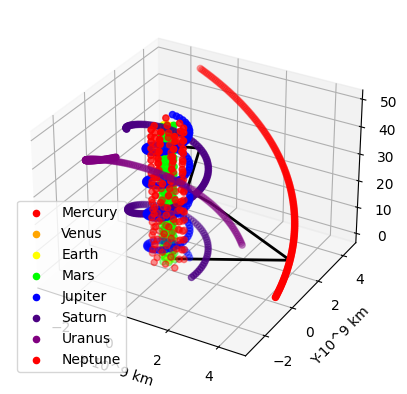

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter

planet = lambda i: ([position[i][k].x for k in range(len(time))],
 [position[i][k].y for k in range(len(time))],
  [position[i][k].t for k in range(len(time))])

x_me, y_me, z_me = planet(0)
x_v, y_v, z_v = planet(1)
x_e, y_e, z_e = planet(2)
x_m, y_m, z_m = planet(3)
x_j, y_j, z_j = planet(4)
x_s, y_s, z_s = planet(5)
x_u, y_u, z_u = planet(6)
x_n, y_n, z_n = planet(7)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

col = ['#FF0000', '#FFA500', '#FFFF00', '#00FF00', '#0000FF', '#4B0082', '#800080']

ax.scatter(x_me, y_me, z_me, label='Mercury', c=col[0], marker='o')
ax.scatter(x_v, y_v, z_v, label='Venus', c=col[1], marker='o')
ax.scatter(x_e, y_e, z_e, label='Earth', c=col[2], marker='o')
ax.scatter(x_m, y_m, z_m, label='Mars', c=col[3], marker='o')
ax.scatter(x_j, y_j, z_j, label='Jupiter', c=col[4], marker='o')
ax.scatter(x_s, y_s, z_s, label='Saturn', c=col[5], marker='o')
ax.scatter(x_u, y_u, z_u, label='Uranus', c=col[6], marker='o')
ax.scatter(x_n, y_n, z_n, label='Neptune', c=col[0], marker='o')

n = 0
# path, distance, time, next neighbor
one_path = ant_path(position[2][0], [], [], [], 0, 0)
while n < 50 and len(one_path[0]) < 9:
  one_path = ant_path(position[2][0], [], [], [], 0, 0)
  n += 1

  #print( (n, len(one_path)) )

line = [[p.x, p.y, p.t] for p in one_path[0]]
print(np.matrix(line))
print(one_path[1], 'distance')
print(one_path[2], 'time')
print(one_path[3], 'index of the next neighbor')
print([p.it for p in one_path[0]], 'order of travel')
#print(list( map(itemgetter(2), line )))
ax.plot(list( map(itemgetter(0), line )), list( map(itemgetter(1), line )), list( map(itemgetter(2), line )), color='k', linewidth=2)

ax.set_xlabel('x-10^9 km')
ax.set_ylabel('Y-10^9 km')
ax.set_zlabel('Years')
ax.legend()
plt.show()


In [ ]:
import numpy as np
((np.linalg.norm(np.array([4.38, 1.096]) - np.array([-0.04778, 2.8667])) / (9.328 - 7.832)) * 10**9) / (24 * 365) # km / hr



363886.04073045414